In [1]:
# !pip install shap

# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score 
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import xgboost as xgb
import shap

import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [3]:
df = pd.read_csv("customer_purchase_data.csv")

In [4]:
df.head()

,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus
0,40,1,66120.267939,8,0,30.568601,0,5,1
1,20,1,23579.773583,4,2,38.240097,0,5,0
2,27,1,127821.306432,11,2,31.633212,1,0,1
3,24,1,137798.623120,19,3,46.167059,0,4,1
4,31,1,99300.964220,19,1,19.823592,0,0,1


In [5]:
df.shape

(1500, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 1500 non-null   int64  
 1   Gender              1500 non-null   int64  
 2   AnnualIncome        1500 non-null   float64
 3   NumberOfPurchases   1500 non-null   int64  
 4   ProductCategory     1500 non-null   int64  
 5   TimeSpentOnWebsite  1500 non-null   float64
 6   LoyaltyProgram      1500 non-null   int64  
 7   DiscountsAvailed    1500 non-null   int64  
 8   PurchaseStatus      1500 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 105.6 KB


# Handle Missing Values

In [7]:
df.isnull().sum()

Age                   0
Gender                0
AnnualIncome          0
NumberOfPurchases     0
ProductCategory       0
TimeSpentOnWebsite    0
LoyaltyProgram        0
DiscountsAvailed      0
PurchaseStatus        0
dtype: int64

# Outlier Detection

In [8]:
numeric_cols = df.select_dtypes(include=np.number).columns

outlier_summary = {}

for col in numeric_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    outlier_summary[col] = len(outliers)

# Display number of outliers in each column
outlier_df = pd.DataFrame(list(outlier_summary.items()), columns=['Feature','Number_of_Outliers'])
outlier_df

,Feature,Number_of_Outliers
0,Age,0
1,Gender,0
2,AnnualIncome,0
3,NumberOfPurchases,0
4,ProductCategory,0
5,TimeSpentOnWebsite,0
6,LoyaltyProgram,0
7,DiscountsAvailed,0
8,PurchaseStatus,0


# EDA

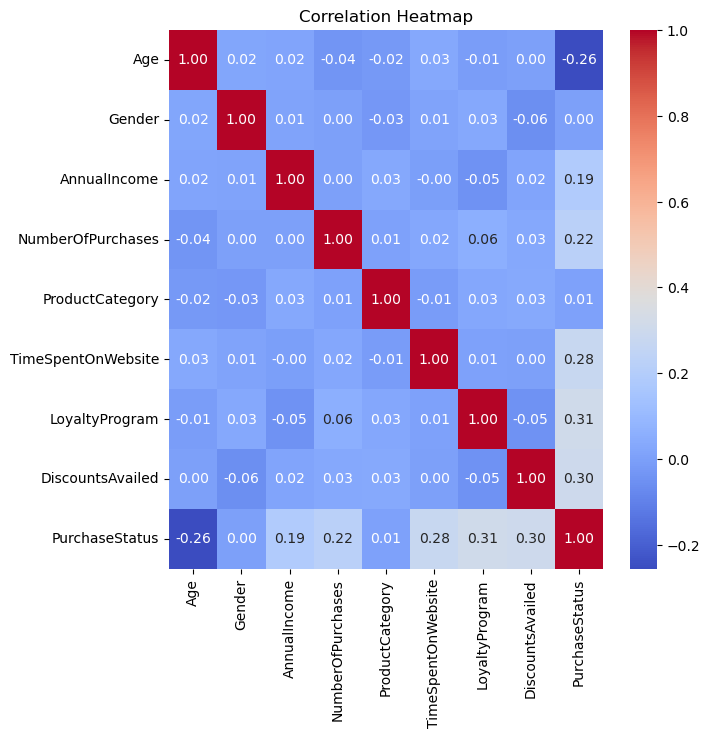

In [9]:
plt.figure(figsize=(7,7))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()

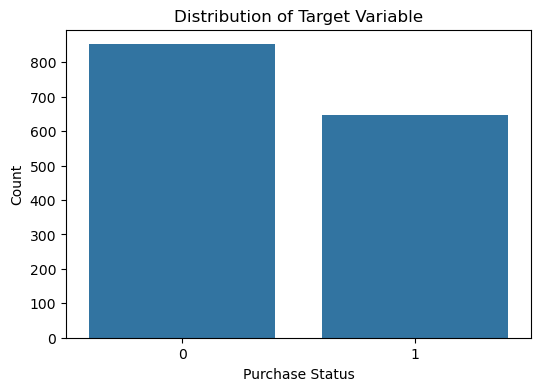

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(x='PurchaseStatus', data=df)

plt.title("Distribution of Target Variable")
plt.xlabel("Purchase Status")
plt.ylabel("Count")

plt.show()

In [11]:
label_encoder = LabelEncoder()

if df['ProductCategory'].dtype == 'object':
    df['ProductCategory'] = label_encoder.fit_transform(df['ProductCategory'])

# Feature Engineering

In [12]:
# Engagement Score
df['EngagementScore'] = (
    0.5 * df['TimeSpentOnWebsite'] +
    0.3 * df['NumberOfPurchases'] +
    0.2 * df['DiscountsAvailed']
)

In [13]:
# Recency-Frequency Indicator
df['RecencyFrequency'] = df['NumberOfPurchases'] / (df['TimeSpentOnWebsite'] + 1)

In [14]:
# Customer Activity Index
df['CustomerActivityIndex'] = (
    df['NumberOfPurchases'] * df['TimeSpentOnWebsite']
)

In [15]:
# Income Level Binning
df['IncomeLevel'] = pd.qcut(df['AnnualIncome'], 3, labels=[0,1,2])

In [16]:
# Interaction Feature
df['TimePurchaseInteraction'] = df['TimeSpentOnWebsite'] * df['NumberOfPurchases']

# Feature and Target Split

In [17]:
X = df.drop('PurchaseStatus', axis=1)
y = df['PurchaseStatus']

# Standardization

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Logistic Regression (Baseline Model)

In [20]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [21]:
# Prediction
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

In [22]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_log))

Accuracy: 0.84


In [23]:
print("Precision:", precision_score(y_test, y_pred_log))

Precision: 0.8773584905660378


In [24]:
print("Recall:", recall_score(y_test, y_pred_log))

Recall: 0.7265625


In [25]:
print("F1 Score:", f1_score(y_test, y_pred_log))

F1 Score: 0.7948717948717948


In [26]:
print("ROC AUC:", roc_auc_score(y_test, y_prob_log))


ROC AUC: 0.8949400436046512


In [27]:
print(confusion_matrix(y_test, y_pred_log))

[[159  13]
 [ 35  93]]


In [28]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.82      0.92      0.87       172
           1       0.88      0.73      0.79       128

    accuracy                           0.84       300
   macro avg       0.85      0.83      0.83       300
weighted avg       0.84      0.84      0.84       300



# Random Forest (With Hyperparameter Tuning)

In [29]:
rf_model = RandomForestClassifier()

rf_params = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None]
}

rf_grid = GridSearchCV(
    rf_model,
    rf_params,
    cv=5,
    scoring='accuracy'
)

rf_grid.fit(X_train, y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': [5, 10, ...], 'n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [30]:
best_rf = rf_grid.best_estimator_

In [31]:
# Prediction
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:,1]

In [32]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.9333333333333333


In [33]:
print("Precision:", precision_score(y_test, y_pred_rf))

Precision: 0.95


In [34]:
print("Recall:", recall_score(y_test, y_pred_rf))

Recall: 0.890625


In [35]:
print("F1 Score:", f1_score(y_test, y_pred_rf))

F1 Score: 0.9193548387096774


In [36]:
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))

ROC AUC: 0.9557821584302324


In [37]:
print(confusion_matrix(y_test, y_pred_rf))

[[166   6]
 [ 14 114]]


In [38]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94       172
           1       0.95      0.89      0.92       128

    accuracy                           0.93       300
   macro avg       0.94      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300



# Gradient Boosting

In [39]:
gb_model = GradientBoostingClassifier()

gb_params = {
    'n_estimators':[100,200],
    'learning_rate':[0.01,0.1],
    'max_depth':[3,5]
}

gb_grid = GridSearchCV(
    gb_model,
    gb_params,
    cv=5,
    scoring='accuracy'
)

gb_grid.fit(X_train, y_train)

,estimator,GradientBoostingClassifier()
,param_grid,"{'learning_rate': [0.01, 0.1], 'max_depth': [3, 5], 'n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [40]:
best_gb = gb_grid.best_estimator_

In [41]:
# Prediction
y_pred_gb = best_gb.predict(X_test)
y_prob_gb = best_gb.predict_proba(X_test)[:,1]

In [42]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_gb))

Accuracy: 0.94


In [43]:
print("Precision:", precision_score(y_test, y_pred_gb))

Precision: 0.9661016949152542


In [44]:
print("Recall:", recall_score(y_test, y_pred_gb))

Recall: 0.890625


In [45]:
print("F1 Score:", f1_score(y_test, y_pred_gb))

F1 Score: 0.926829268292683


In [46]:
print("ROC AUC:", roc_auc_score(y_test, y_prob_gb))

ROC AUC: 0.9502407340116279


In [47]:
print(confusion_matrix(y_test, y_pred_gb))

[[168   4]
 [ 14 114]]


In [48]:
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.92      0.98      0.95       172
           1       0.97      0.89      0.93       128

    accuracy                           0.94       300
   macro avg       0.94      0.93      0.94       300
weighted avg       0.94      0.94      0.94       300



# XGBoost

In [49]:
xgb_model = xgb.XGBClassifier(eval_metric='logloss')

xgb_params = {
    'n_estimators':[100,200],
    'learning_rate':[0.01,0.1],
    'max_depth':[3,6]
}

xgb_grid = GridSearchCV(
    xgb_model,
    xgb_params,
    cv=5,
    scoring='accuracy'
)

xgb_grid.fit(X_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'learning_rate': [0.01, 0.1], 'max_depth': [3, 6], 'n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [50]:
best_xgb = xgb_grid.best_estimator_

In [51]:
# Prediction
y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:,1]

In [52]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

Accuracy: 0.95


In [53]:
print("Precision:", precision_score(y_test, y_pred_xgb))

Precision: 0.9829059829059829


In [54]:
print("Recall:", recall_score(y_test, y_pred_xgb))

Recall: 0.8984375


In [55]:
print("F1 Score:", f1_score(y_test, y_pred_xgb))

F1 Score: 0.9387755102040817


In [56]:
print("ROC AUC:", roc_auc_score(y_test, y_prob_xgb))

ROC AUC: 0.9495821220930232


In [57]:
print(confusion_matrix(y_test, y_pred_xgb))

[[170   2]
 [ 13 115]]


In [58]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96       172
           1       0.98      0.90      0.94       128

    accuracy                           0.95       300
   macro avg       0.96      0.94      0.95       300
weighted avg       0.95      0.95      0.95       300



# Feature Importance (Random Forest)

In [59]:
importances = best_rf.feature_importances_

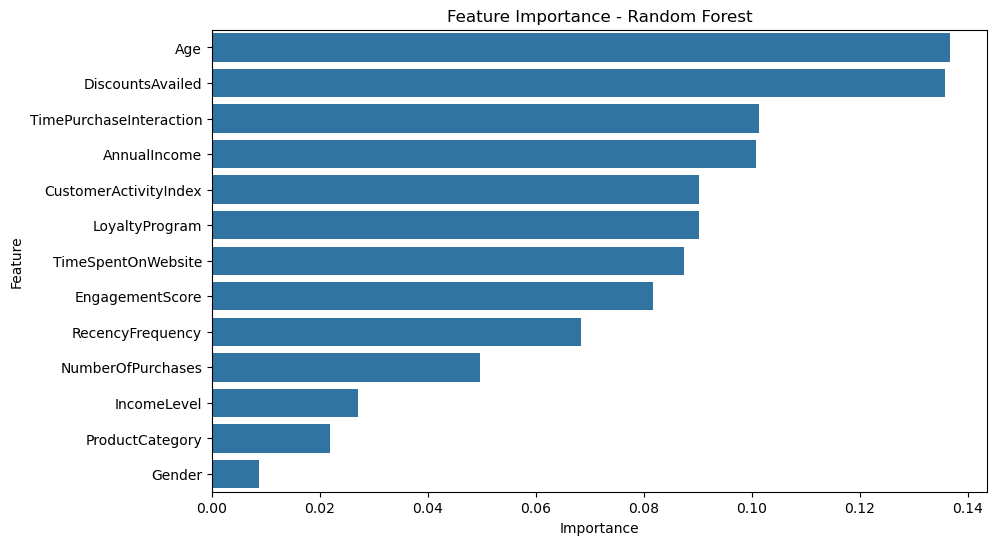

In [60]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance, x='Importance', y='Feature')

plt.title("Feature Importance - Random Forest")
plt.show()

# ROC Curve Comparison

In [61]:
# Calculate ROC curve
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
roc_auc_log = auc(fpr_log, tpr_log)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
roc_auc_gb = auc(fpr_gb, tpr_gb)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

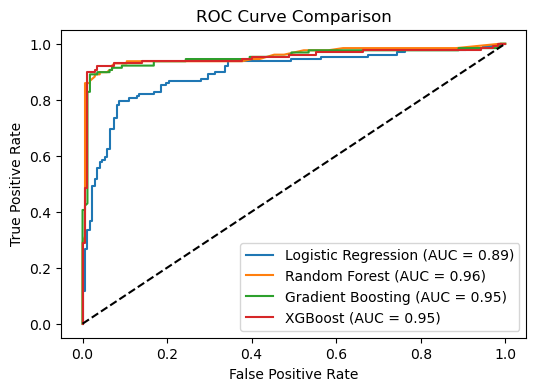

In [62]:
plt.figure(figsize=(6,4))

plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc_log:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {roc_auc_gb:.2f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.2f})')

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

# Model Performance Comparison

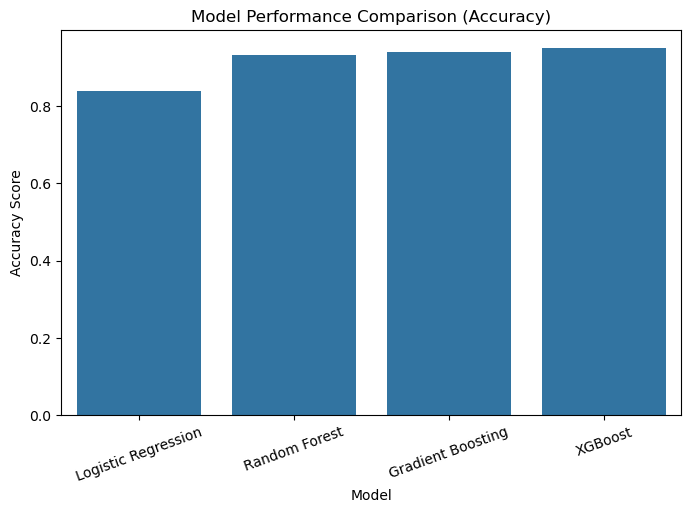

In [63]:
model_names = ['Logistic Regression','Random Forest','Gradient Boosting','XGBoost']

accuracies = [
    accuracy_score(y_test, y_pred_log),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_gb),
    accuracy_score(y_test, y_pred_xgb)
]

results_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies
})

plt.figure(figsize=(8,5))

sns.barplot(data=results_df, x='Model', y='Accuracy')

plt.title("Model Performance Comparison (Accuracy)")
plt.ylabel("Accuracy Score")
plt.xticks(rotation=20)

plt.show()

# SHAP Model Interpretability (Using XGBoost)

In [64]:
# Create explainer
explainer = shap.TreeExplainer(best_xgb)

In [65]:
# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

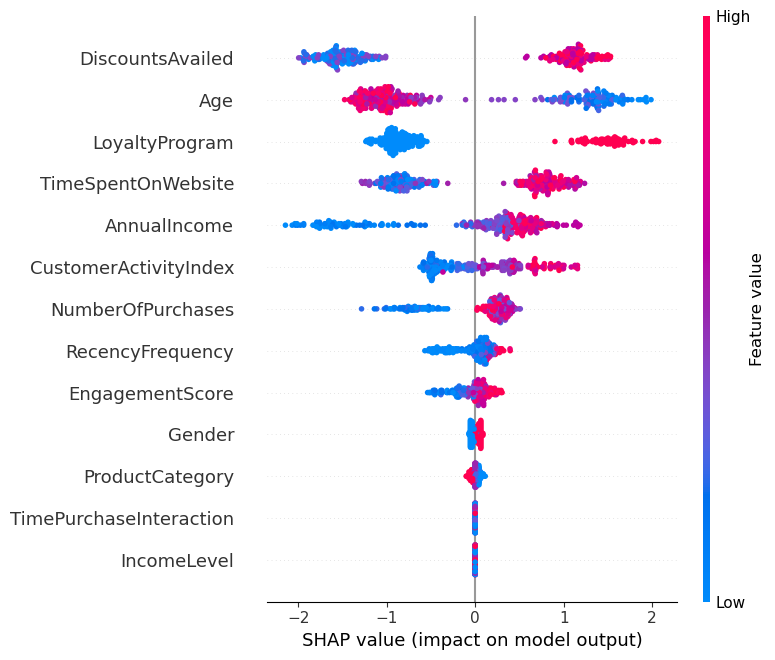

In [66]:
# Summary plot
shap.summary_plot(shap_values, X_test, feature_names=X.columns)